# Лабораториска Вежба 1 – Класификација
### MAGIC Gamma Telescope

In [1]:
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Вчитување

In [ ]:
magic = fetch_ucirepo(id=159)
X = magic.data.features.values
y = magic.data.targets.values.ravel()

## 2. Визуелизации

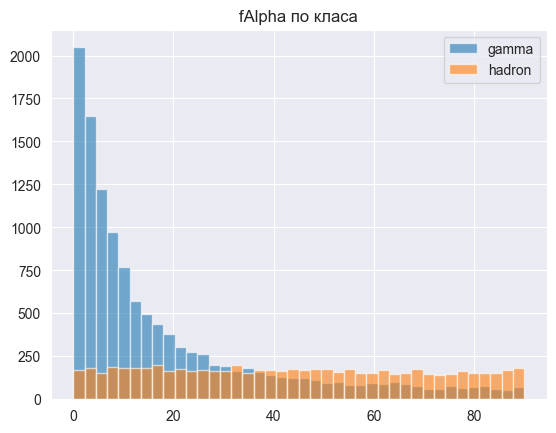

In [11]:
plt.hist(X[y == 'g', 8], bins=40, alpha=0.6, label='gamma')
plt.hist(X[y == 'h', 8], bins=40, alpha=0.6, label='hadron')
plt.title('fAlpha по класа')
plt.legend()
plt.show()

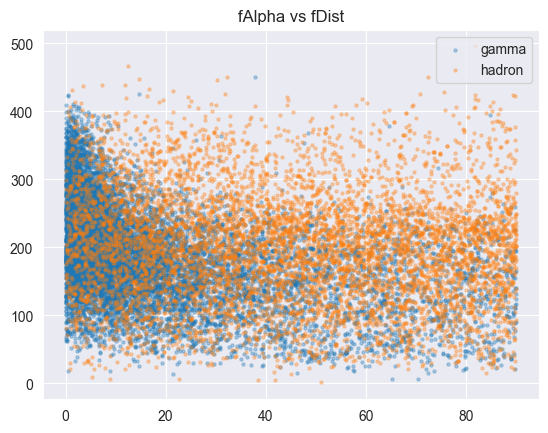

In [12]:
plt.scatter(X[y == 'g', 8], X[y == 'g', 9], alpha=0.3, label='gamma', s=5)
plt.scatter(X[y == 'h', 8], X[y == 'h', 9], alpha=0.3, label='hadron', s=5)
plt.title('fAlpha vs fDist')
plt.legend()
plt.show()

## 3. Поделба и тренирање

In [13]:
split = int(0.8 * len(X))
train_x, test_x = X[:split], X[split:]
train_y, test_y = y[:split], y[split:]

models = {'Naive Bayes': GaussianNB(), 'LDA': LDA(), 'QDA': QDA()}
for model in models.values():
    model.fit(train_x, train_y)

## 4. Споредба

In [14]:
for name, model in models.items():
    print(f'{name}: {accuracy_score(test_y, model.predict(test_x)):.4f}')

Naive Bayes: 0.3478
LDA: 0.4253
QDA: 0.4482


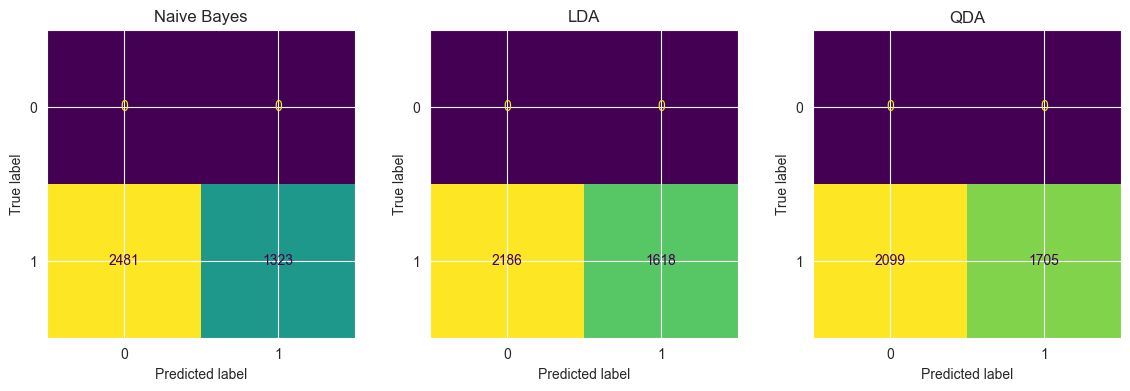

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay(confusion_matrix(test_y, model.predict(test_x))).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.show()

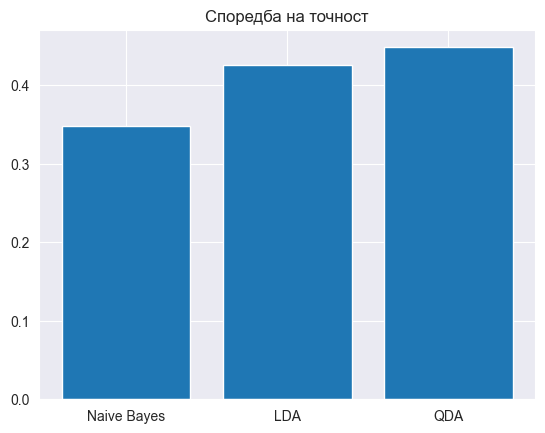

In [16]:
accs = [accuracy_score(test_y, m.predict(test_x)) for m in models.values()]
plt.bar(models.keys(), accs)
plt.title('Споредба на точност')
plt.show()